# Contextual Associative Bandits [CAB]

## Part 1: Defining The Inference System

In [1]:
import torch

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
from idealobserver import IdealObsPFJCRP
from experiment import (
    ExperimentalEnvCRP,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from particle import print_particle_params

In [7]:
import torch
from conjugates import ConjugateOptimalArm


def manual_posterior(beta0, rho_c, rho_i, succ, fail):
    weights = beta0 * (rho_c / rho_i) ** succ * ((1 - rho_c) / (1 - rho_i)) ** fail
    return weights / weights.sum()


# Simple example
rho_c = 0.8
rho_i = 0.2

beta0 = torch.tensor([1 / 3, 1 / 3, 1 / 3])

model = ConjugateOptimalArm(
    rho_c=rho_c,
    rho_i=rho_i,
    beta0=beta0,
)

# Reward from arm 0
model.update(a=0, r=1.0)

expected = manual_posterior(
    beta0,
    rho_c,
    rho_i,
    succ=torch.tensor([1.0, 0.0, 0.0]),
    fail=torch.tensor([0.0, 0.0, 0.0]),
)

print("Model:   ", model.beta_n)
print("Expected:", expected)

assert torch.allclose(model.beta_n, expected, atol=1e-6)

print("PASS")

Model:    tensor([0.6667, 0.1667, 0.1667])
Expected: tensor([0.6667, 0.1667, 0.1667])
PASS


In [8]:
rho_c = 0.8
rho_i = 0.2
beta0 = torch.tensor([1 / 3, 1 / 3, 1 / 3])

model = ConjugateOptimalArm(rho_c, rho_i, beta0)

print("Before:", model.beta_n)

model.update(a=0, r=1.0)

print("After reward on arm 0:", model.beta_n)

assert model.beta_n[0] > beta0[0]
assert model.beta_n[1] < beta0[1]
assert model.beta_n[2] < beta0[2]

Before: tensor([0.3333, 0.3333, 0.3333])
After reward on arm 0: tensor([0.6667, 0.1667, 0.1667])


In [10]:
rho_c = 0.8
rho_i = 0.2
beta0 = torch.tensor([1 / 3, 1 / 3, 1 / 3])

model = ConjugateOptimalArm(rho_c, rho_i, beta0)
print("Before:", model.beta_n)

model.update(a=0, r=0.0)
print("After reward on arm 0:", model.beta_n)

assert model.beta_n[0] < beta0[0]
assert model.beta_n[1] > beta0[1]
assert model.beta_n[2] > beta0[2]

Before: tensor([0.3333, 0.3333, 0.3333])
After reward on arm 0: tensor([0.1111, 0.4444, 0.4444])


## Part 1: Defining the experiment

### Define the various contexts that can be encountered

In [3]:
NOISE = 0.02
cov_all = torch.eye(2) * NOISE

loc_c0_s0 = torch.tensor([1.0, 0.0])
loc_c0_s1 = torch.tensor([-1.0, 0.0])

loc_c1_s0 = torch.tensor([0.0, 1.0])
loc_c1_s1 = torch.tensor([0.0, -1.0])

loc_c2_s0 = torch.tensor([0.5, 0.5])
loc_c2_s1 = torch.tensor([-0.5, 0.5])

context_o_params = {
    0: {  # context 0
        0: {"loc": loc_c0_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c0_s1, "cov": cov_all},  # state 1
    },
    1: {  # context 1
        0: {"loc": loc_c1_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c1_s1, "cov": cov_all},  # state 1
    },
    2: {  # context 0
        0: {"loc": loc_c0_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c0_s1, "cov": cov_all},  # state 1
        # 0: {"loc": loc_c2_s0, "cov": cov_all},  # state 0
        # 1: {"loc": loc_c2_s1, "cov": cov_all},  # state 1
    },
}

context_r_params = {
    0: {  # context 0
        0: {"p_rew": torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 1.0, 0.0, 0.0])},  # state 1
    },
    1: {  # context 1
        0: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 0.0, 0.0, 1.0])},  # state 1
    },
    2: {  # context 1
        0: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 0.0, 0.0, 1.0])},  # state 1
        # 0: {"p_rew": torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        # 1: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 1
    },
}

In [4]:
env = ExperimentalEnvCRP(
    context_o_params=context_o_params, context_r_params=context_r_params
)

## Part 2: Run Simulation

In [5]:
HYP_JCRP = {
    "gamma": 0.1,
    "alpha": 10,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.1,
    "nu0": 4.0,
    "Lambda0": torch.eye(2) * 1.0,
}
HYP_BB = {
    # "alpha0": torch.tensor([0.05, 0.05, 0.05, 0.05]),
    "beta0": torch.tensor([0.25, 0.25, 0.25, 0.25]),
    "rho_c": 0.9,
    "rho_i": 0.1,
    # "prior": torch.tensor([0.25, 0.25, 0.25, 0.25]),
}

HYP = {"hyp_jcrp": HYP_JCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}

#### Simulation

In [6]:
results = []

for i in range(1):

    # Initialize history buffers
    exp_history = ExperimentHistory()
    sub_history = IOPFSubjectHistory()

    # Initialize ensemble
    subject = IdealObsPFJCRP(N=250, hyp_params=HYP, n_workers=8)
    # ensemble = Ensemble(N=1000, hyp_jcrp=HYP_JCRP, hyp_niw=HYP_NIW, hyp_bb=HYP_BB)

    # Run 50 trials in context (c_=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=0,
        print_level=3,
    )
    # Run 50 trials in context (c=1)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=1,
        print_level=3,
    )

    # Run 50 trials in context (c_=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=0,
        print_level=3,
    )

    # Run 50 trials in context (c_=2)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=2,
        print_level=3,
    )

    subject.deallocate()

    # Combine histories into single object
    combined_history = CombinedHistory(
        subject_history=sub_history, experiment_history=exp_history
    )

    results.append(combined_history)

    plt.figure(figsize=(10, 3))
    plt.plot(
        combined_history.experiment_history.reward,
        label="Reward",
        color="blue",
        linewidth=2,
    )
    plt.title("Reward Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Reward")
    plt.ylim(-0.1, 1.1)
    plt.show()


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.94  0.08], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 2:   	True state: 1, Obs.: [-0.83 -0.08], Action: 0, Reward: 0.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 3:   	True state: 0, Obs.: [ 0.96 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 4:   	True state: 1, Obs.: [-1.15  0.11], Action: 0, Reward: 0.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 5:   	True state: 0, Obs.: [ 0.91  0.06], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 6:   	True state: 0, Obs.: [ 0.99 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 7:   	True state: 1, Obs.: [-0.97 -0.09], Action: 0, Reward: 0.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 1.03 -0.18], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.06  0.23], Action:

Process SpawnProcess-6:
Process SpawnProcess-8:
Process SpawnProcess-2:
Process SpawnProcess-1:
Process SpawnProcess-4:
Process SpawnProcess-3:
Process SpawnProcess-5:
Process SpawnProcess-7:
Traceback (most recent call last):
  File "/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/youjingyu/code/CCAB/idealobserver.py", line 61, in pf_worker_loop
    particle.before_action(o_t)
  File "/Users/youjingyu/code/CCAB/particle.py", line 845, in before_action
    self._obs_lh = self.obs_likelihood(o_t)
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/youjingyu/code/CCAB/particle.py", line 803, in obs_likelihood
    likelihoods[i, j] = self.obs_models[i][j].pred_lh(o_t)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/youjin

KeyboardInterrupt: 

In [ ]:
# for particle in subject.particles:
#     print(f"\n>> Particle {particle}:\n")
#     print_particle_params(particle)

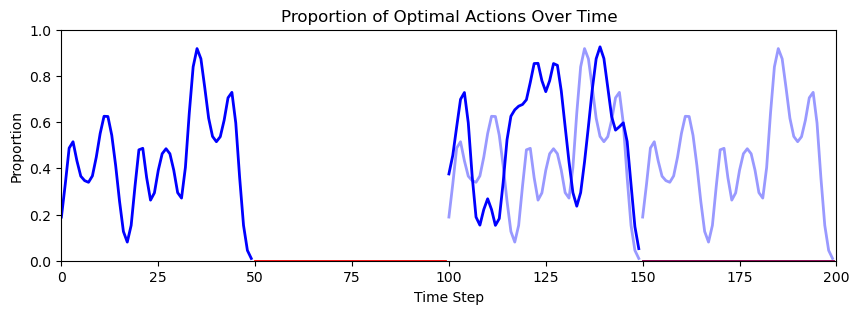

In [ ]:
proportion_optimal_mean = np.zeros(200)

chosen = list(range(1))

for j in chosen:

    proportion_optimal_mean += np.array(results[j].experiment_history.reward)

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


task_1 = smooth(proportion_optimal_mean[0:50])
task_1_dur = np.arange(0, 50)
task_2 = smooth(proportion_optimal_mean[50:100])
task_2_dur = np.arange(50, 100)
task_3 = smooth(proportion_optimal_mean[100:150])
task_3_dur = np.arange(100, 150)
task_4 = smooth(proportion_optimal_mean[150:200])
task_4_dur = np.arange(150, 200)


plt.figure(figsize=(10, 3))
# plt.plot(proportion_optimal_mean, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.plot(task_1_dur, task_1, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_2_dur, task_2, color="red", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_3, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_4_dur, task_4, color="indigo", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_2, color="red", linewidth=2, alpha=0.4)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(proportion_optimal_mean))
# plt.savefig("g_proportion_optimal_3.pdf")
plt.show()

## Part 3: Analysis of Results

#### Sanity check of inferred parameters

### Visualisation of Results

In [ ]:
print(type(results[j]))
print(vars(results[j]).keys())
print(vars(results[j].experiment_history).keys())
print(vars(results[j].subject_history).keys())

<class 'experiment.CombinedHistory'>
dict_keys(['experiment_history', 'subject_history'])
dict_keys(['state', 'context_o', 'context_r', 'observation', 'optimal_action', 'action', 'reward'])
dict_keys(['p_action', 'p_state', 'p_jump', 'context_o', 'context_r', 'weights'])


Context History:


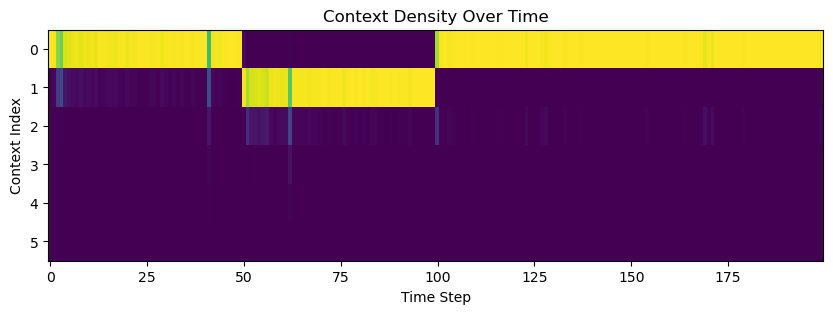

Actions History:


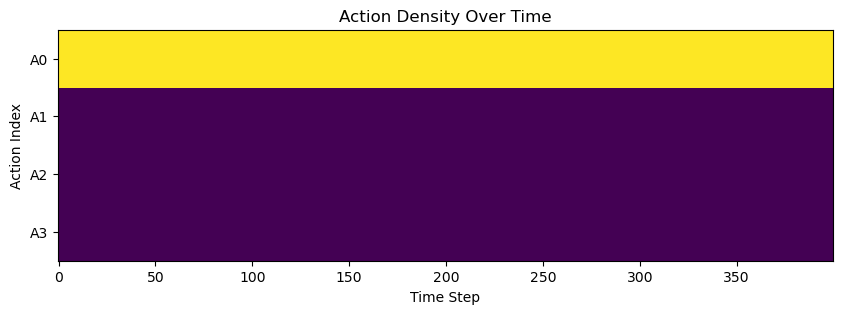

Proportion of Optimal Actions Over Time:


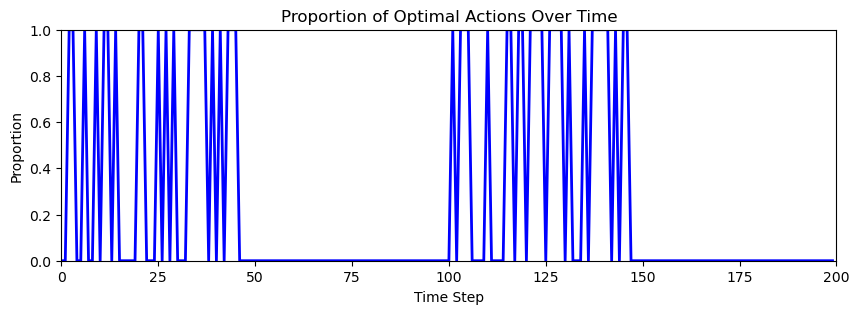

Jump History:


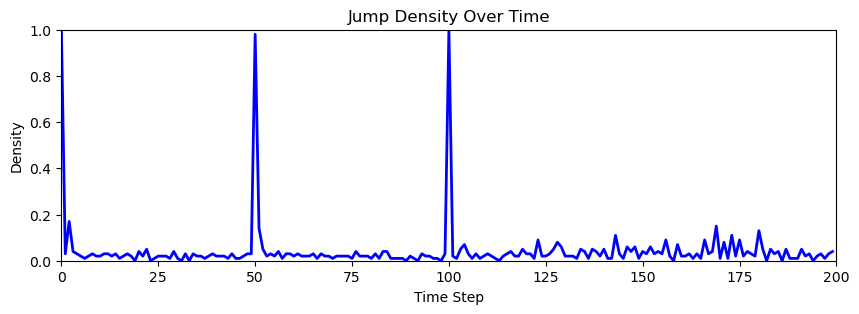

Inferred S History:


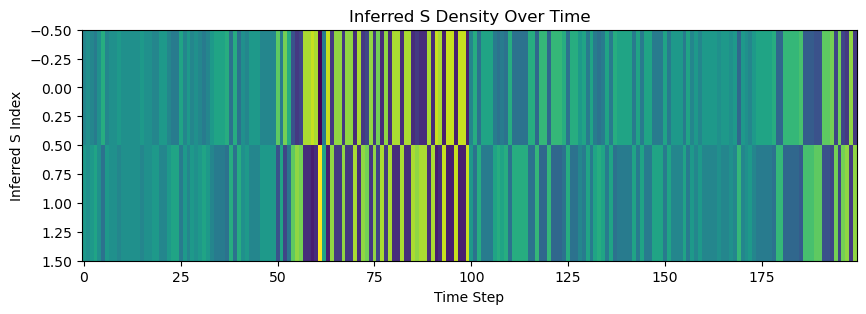

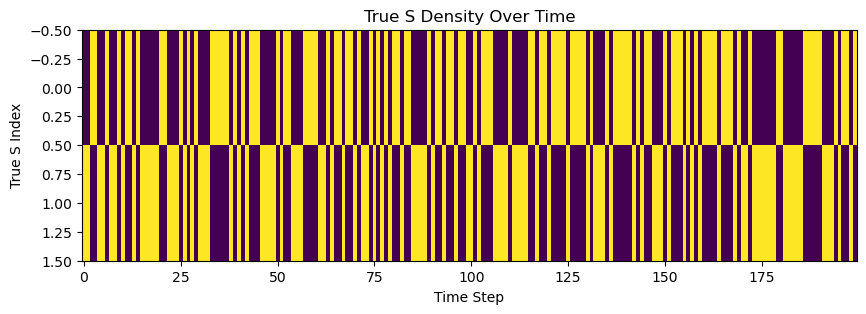

In [ ]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context Density Over Time")
# plt.savefig("g_context_o_density.pdf")
plt.show()


print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(results[j].experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, val] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
# plt.savefig("g_true_s_density.pdf")
plt.show()